<a href="https://colab.research.google.com/github/Nkeeydata/House_Predictor_Model/blob/main/Nkechika_AICA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Capstone for AICA Project

### **Problem Statement** :

A real estate firm wants to understand what drives house prices in their market and build a tool to estimate a fair listing price for a property based on its characteristics. Specifically, they want to know:

1. Which features — square footage, number of bedrooms/bathrooms, stories, parking, amenities like air conditioning or a guest room, and location desirability (main road access, preferred area)- have the strongest influence on price
2. Can a model predict the price of a new/unlisted house accurately enough to support pricing decisions (e.g., setting an asking price, flagging overpriced/underpriced listings, or helping buyers negotiate)?

### About the Dataset / Data Dictionary

1. Price: The price of the house  
2. Area: The total area of the house in square feet  
3. Bedrooms: The number of bedrooms in the house  
4. Bathrooms: The number of bathrooms in the house  
5. Stories: The number of stories in the house  
6. Mainroad: Whether the house is connected to the main road (Yes/No)  
7. Guestroom: Whether the house has a guest room (Yes/No)  
8. Basement: Whether the house has a basement (Yes/No)  
9. Hot water heating: Whether the house has a hot water heating system (Yes/No)  
10. Airconditioning: Whether the house has an air conditioning system (Yes/No)  
11. Parking: The number of parking spaces available within the house  
12. Prefarea: Whether the house is located in a preferred are13. Furnishing status: The furnishing status of the house (Fully Furnished, Semi-Furnished, Unfurnished)ai-Furnished, Unfurnished).

### *1* DATA PREPROCESSING

### Importation of Libraries

In [ ]:
#importation of operational libraries
import numpy as np
import pandas as pd

#visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

#importation of machine learning libraries
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.linear_model import RidgeCV
from sklearn.tree   import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

#model saving library
import joblib

In [ ]:
df = pd.read_csv("Housing.csv") #importing of dataset

In [ ]:
df.head() #viewing the first five rows of the dataset to understand the features

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df_copy = df.copy() # duplicating the dataset incase of error

In [ ]:
df.describe() # to view the centre of tendencies like the mean, median

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


#### it shows that the prices of the houses fell between ```2,896,289``` and ```6,637,169``` due to the mean and standard deviation being ```4,766,729``` and ```1,870,440``` respectively following the formula mean±standard deviation

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


#### The above information reviews that there is no null values in all the columns since we have ```545``` entries and we are recording ```545``` non null entries. It also shows the data types of each feature, and this data set is made up of ```integer``` and ```object``` data types.

In [ ]:
df.isna().sum() #confirming the zero null values for each column

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [ ]:
df.columns #reviewing the column names

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [ ]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

### Encoding of Categorical Variable

#### Confirming their unique values before proceeding with encoding to know which encoding techniques to apply

In [ ]:
df['mainroad'].value_counts()

mainroad
yes    468
no      77
Name: count, dtype: int64

In [ ]:
df['guestroom'].value_counts()

guestroom
no     448
yes     97
Name: count, dtype: int64

In [ ]:
df['basement'].value_counts()

basement
no     354
yes    191
Name: count, dtype: int64

In [ ]:
df['hotwaterheating'].value_counts()

hotwaterheating
no     520
yes     25
Name: count, dtype: int64

In [ ]:
df['airconditioning'].value_counts()

airconditioning
no     373
yes    172
Name: count, dtype: int64

In [ ]:
df['prefarea'].value_counts()

prefarea
no     417
yes    128
Name: count, dtype: int64

In [ ]:
df['furnishingstatus'].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

### Since 6 of my categorical variables have binary values, I will encode them as either 0 or 1 using .map, while applying Ordinal encoding to the furnishingstatus categorical variable with three unique values

In [ ]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})


print(df[binary_cols].head())

   mainroad  guestroom  basement  hotwaterheating  airconditioning  prefarea
0         1          0         0                0                1         1
1         1          0         0                0                1         0
2         1          0         1                0                0         1
3         1          0         1                0                1         1
4         1          1         1                0                1         0


In [ ]:
df.head(3) # confirming the changes

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished


In [ ]:
encoder = OrdinalEncoder(
    categories=[['unfurnished', 'semi-furnished', 'furnished']]
)

df['furnishingstatus'] = encoder.fit_transform(
    df[['furnishingstatus']]
)

print(df['furnishingstatus'].value_counts())

furnishingstatus
1.0    227
0.0    178
2.0    140
Name: count, dtype: int64


In [ ]:
df.head(2) #confirming the ordinal encoding

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2.0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2.0


In [ ]:
df.dtypes # confirming the data types before building model

price                 int64
area                  int64
bedrooms              int64
bathrooms             int64
stories               int64
mainroad              int64
guestroom             int64
basement              int64
hotwaterheating       int64
airconditioning       int64
parking               int64
prefarea              int64
furnishingstatus    float64
dtype: object

In [ ]:
df.isna().sum() # confirming the null values again as well

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

### *2* EXPLORATORY DATA ANALYSIS

#### Generating correlation matrix to the target variable

In [ ]:
corr_matrix = df.corr()

# print it to inspect values
print(corr_matrix)

                     price      area  bedrooms  bathrooms   stories  mainroad  \
price             1.000000  0.535997  0.366494   0.517545  0.420712  0.296898   
area              0.535997  1.000000  0.151858   0.193820  0.083996  0.288874   
bedrooms          0.366494  0.151858  1.000000   0.373930  0.408564 -0.012033   
bathrooms         0.517545  0.193820  0.373930   1.000000  0.326165  0.042398   
stories           0.420712  0.083996  0.408564   0.326165  1.000000  0.121706   
mainroad          0.296898  0.288874 -0.012033   0.042398  0.121706  1.000000   
guestroom         0.255517  0.140297  0.080549   0.126469  0.043538  0.092337   
basement          0.187057  0.047417  0.097312   0.102106 -0.172394  0.044002   
hotwaterheating   0.093073 -0.009229  0.046049   0.067159  0.018847 -0.011781   
airconditioning   0.452954  0.222393  0.160603   0.186915  0.293602  0.105423   
parking           0.384394  0.352980  0.139270   0.177496  0.045547  0.204433   
prefarea          0.329777  

In [ ]:
# finding how each feature correlates with price only
print(corr_matrix['price'].sort_values(ascending=False))

price               1.000000
area                0.535997
bathrooms           0.517545
airconditioning     0.452954
stories             0.420712
parking             0.384394
bedrooms            0.366494
prefarea            0.329777
furnishingstatus    0.304721
mainroad            0.296898
guestroom           0.255517
basement            0.187057
hotwaterheating     0.093073
Name: price, dtype: float64


#### This shows that ```area``` and ```bathrooms``` are more correlated to price, meaning, the larger the area of the house, the higher the price, same for bathrooms. ```airconditioning``` and ```stories``` are also positively correlated with price. We noticed that ```hotwaterheating``` is the least correlated with ```0.09...``` value, meaning, the price of the house is not largely dependent on the hotwaterheating. We could say, there exist weak or no linear relationship.

### visualizing the Heatmap

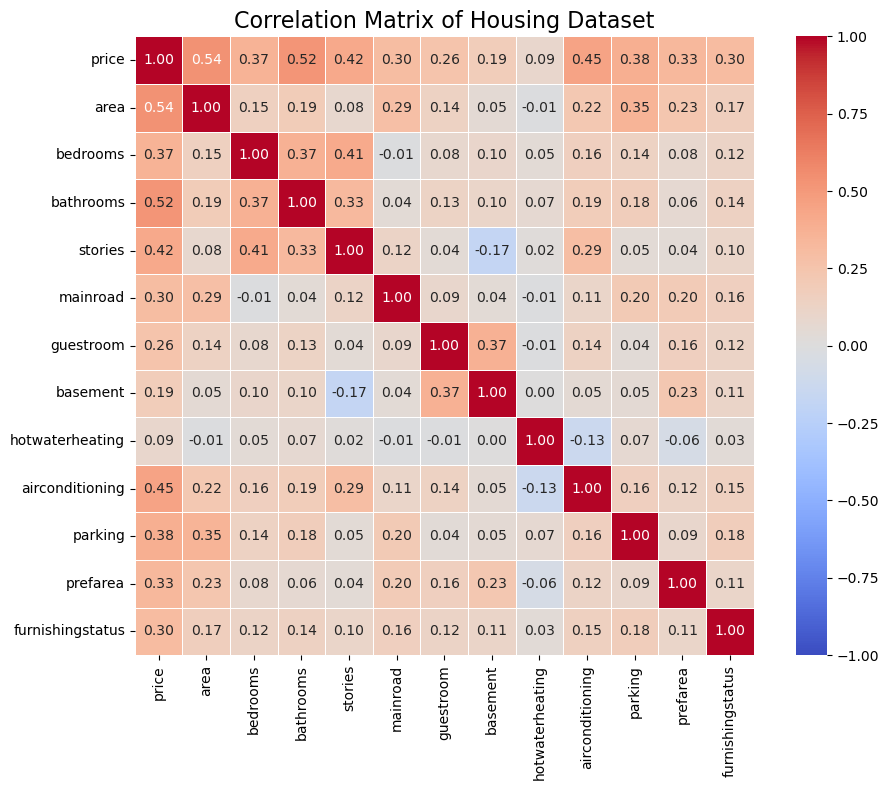

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,          # show numbers inside cells
    fmt='.2f',            # round to 2 decimal places since our values are much
    cmap='coolwarm',     # blue=negative, red=positive
    vmin=-1, vmax=1,     # fix the color scale, if not, seaborn will reframe to my data range
    linewidths=0.5,       # thin grid lines between cells
    square=True           # make cells square-shaped
)

plt.title('Correlation Matrix of Housing Dataset', fontsize=16) #specify the fontsize needed
plt.tight_layout()
plt.show()

In [ ]:
# Printing the top 5 correlated features to price from highest to lowest

# Get correlations with 'price' sorted by absolute value
price_corr = corr_matrix['price'].sort_values(key=abs, ascending=False)

# Top 5 features (excluding 'price' itself)
top5_corr = price_corr[1:6]   # skip 'price' at index 0

print("Top 5 correlated features with price:")
for feature, corr_value in top5_corr.items():
    print(f"{feature}: {corr_value:.2f}")

Top 5 correlated features with price:
area: 0.54
bathrooms: 0.52
airconditioning: 0.45
stories: 0.42
parking: 0.38


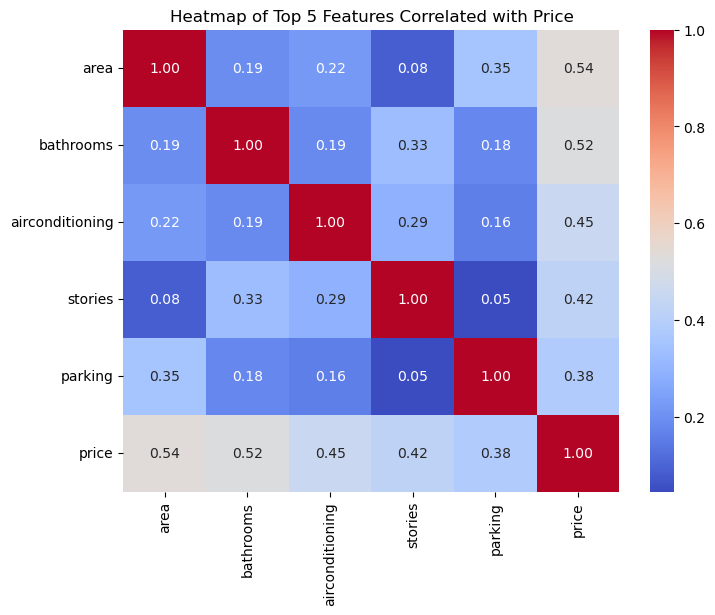

In [ ]:
# Visualizing only the top five correlated in hierarchical order on the heatmap

# Use top5_corr (already sorted correlations with price)
selected_features = top5_corr.index.tolist() + ['price']
plt.figure(figsize=(8,6))
sns.heatmap(df[selected_features].corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap of Top 5 Features Correlated with Price')
plt.show()


#### Above heatmap is displaying the correlation strength to our target variable in hierarchical order with ```area``` having the most correlation

#### Checking for ```Multicollinearity``` among the independent variables to see if any is saying the same message to the model

In [ ]:
X = df.drop(columns=['price'])

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data.sort_values('VIF', ascending=False))

             feature        VIF
1           bedrooms  15.293315
2          bathrooms   9.429678
0               area   8.274080
3            stories   7.886990
4           mainroad   6.871438
11  furnishingstatus   2.727003
6           basement   2.022168
9            parking   1.959942
8    airconditioning   1.748656
10          prefarea   1.486713
5          guestroom   1.468460
7    hotwaterheating   1.089201


#### Since there is high ```Multicollinearity``` among some of the features, with ```bedrooms``` having the most >15, I will drop the ```bedrooms``` feature and redo my ```VIF``` to see if the values will drop to ```below 5```

In [ ]:
df = df.drop(columns=['bedrooms']) # dropping bedrooms column

#### To Note: Dropping ```bedrooms``` doesn't mean its not important to ```price```, it only means, it carries same information that area, bathrooms, stories are also carrying

In [ ]:
df.columns # confirming the removal of bedrooms

Index(['price', 'area', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')

In [ ]:
# re-run VIF on remaining features

X = df.drop(columns=['price'])

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data.sort_values('VIF', ascending=False))

             feature       VIF
1          bathrooms  7.828199
0               area  7.597990
3           mainroad  6.679572
2            stories  6.256601
10  furnishingstatus  2.708045
8            parking  1.959550
5           basement  1.917779
7    airconditioning  1.736419
9           prefarea  1.483424
4          guestroom  1.459461
6    hotwaterheating  1.088804


#### Although, my best VIF value should fall within 5, but I will proceed with the above features and apply ```Ridge``` to regularize the model when building since all values is less than 8

### *3* FEATURE SCALING

#### Performing MinMax scaling on only the continuous variables, not the ones that were encoded, as their values are already within 0 and 1, but values from the continuous variables may be far apart, so the need for scaling

#### I won't be performing scaling until I have separated my data into ```train``` and ```test``` to avoild data leakage

### *4* MODEL TRAINING / SCALING OF TRAIN DATA

In [ ]:
X.columns # have been done previously before performing VIF

Index(['area', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement',
       'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')

In [ ]:
# Assigning the value for y
y = df['price']

#### Splitting using train_tesst_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [ ]:
# Checking No nulls in any split

print('Train nulls:', X_train.isnull().sum().sum())
print('Test nulls :', X_test.isnull().sum().sum())

Train nulls: 0
Test nulls : 0


In [ ]:
# Checking shapes are consistent

print('X_train:', X_train.shape, '| y_train:', y_train.shape)
print('X_test :', X_test.shape,  '| y_test :', y_test.shape)

X_train: (436, 11) | y_train: (436,)
X_test : (109, 11) | y_test : (109,)


#### Performing Scaling on the train Feature alone

In [ ]:
scaler = StandardScaler() # assigning the variable scaler to the preprocessing tool

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

#### Converting back to DataFrame

In [ ]:
# convert back to dataframe to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print(X_train_scaled.describe().round(2))

         area  bathrooms  stories  mainroad  guestroom  basement  \
count  436.00     436.00   436.00    436.00     436.00    436.00   
mean    -0.00       0.00    -0.00      0.00      -0.00      0.00   
std      1.00       1.00     1.00      1.00       1.00      1.00   
min     -1.55      -0.57    -0.93     -2.53      -0.46     -0.70   
25%     -0.72      -0.57    -0.93      0.40      -0.46     -0.70   
50%     -0.26      -0.57     0.21      0.40      -0.46     -0.70   
75%      0.57       1.48     0.21      0.40      -0.46      1.43   
max      5.17       3.52     2.51      0.40       2.16      1.43   

       hotwaterheating  airconditioning  parking  prefarea  furnishingstatus  
count           436.00           436.00   436.00    436.00            436.00  
mean             -0.00            -0.00    -0.00     -0.00             -0.00  
std               1.00             1.00     1.00      1.00              1.00  
min              -0.20            -0.69    -0.82     -0.57             

#### Performing Sanity Check again after scaling using the scaled variables

In [ ]:
# Printing non nulls in any split
print('Train nulls:', X_train_scaled.isna().sum().sum())
print('Test nulls :', X_test_scaled.isna().sum().sum())

# Printing to ensure shapes are consistent
print('X_train:', X_train_scaled.shape, '| y_train:', y_train.shape)
print('X_test :', X_test_scaled.shape,  '| y_test :', y_test.shape)

# printing to show no object-type columns remain
print(X_train_scaled.dtypes.value_counts())

# Printing to show target distribution looks reasonable
print(y_train.describe().round(2))

Train nulls: 0
Test nulls : 0
X_train: (436, 11) | y_train: (436,)
X_test : (109, 11) | y_test : (109,)
float64    11
Name: count, dtype: int64
count         436.00
mean      4777635.18
std       1911167.04
min       1750000.00
25%       3430000.00
50%       4378500.00
75%       5810000.00
max      13300000.00
Name: price, dtype: float64


#### Explaining the above cell printout
1. We could see from the above that both our train and test set contain non null values  
2. We could also see that their shapes are as it should be. same shape in the area concern  
3. We could also see that their data types remains integer which is necessary for building models
4. We could see that the values for the describe, which contains mean, standard deviation and lots more looks good

#### Applying Ridge Regularization to reduce the Multicollinearity in some features which is more than 5

In [ ]:
ridge = Ridge(alpha=10)   # alpha controls penalty strength
ridge.fit(X_train_scaled, y_train)

Ridge(alpha=10)

### *5* MODEL EVALUATION

### BASELINE MODEL

In [ ]:
# This will return the  R²  value

print('R² score:', ridge.score(X_test_scaled, y_test).round(3))


R² score: 0.658


In [ ]:
y_pred = ridge.predict(X_test_scaled)

In [ ]:
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

Mean Absolute Error: 710750.9247561644


In [ ]:

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("Mean Absolute Percentage Error:", mape)


Mean Absolute Percentage Error: 15.753622646597186


#### Seeing that my model deviates from the actual value by 16% average, I will perform hyperparameter tuning and re-predict to see if a better prediction will show forth

### HYPERPARAMETER TUNING

In [ ]:
# alphas to search across — from very weak to very strong penalty
alphas = [0.01, 0.1, 1, 5, 10, 50,
          100, 500, 1000, 5000]

ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train_scaled, y_train)

print('Best alpha  :', ridge_cv.alpha_)
print('CV R² score :', ridge_cv.best_score_.round(3))

Best alpha  : 50.0
CV R² score : 0.656


In [ ]:
# use best alpha found by RidgeCV
best_alpha = ridge_cv.alpha_

final_model = Ridge(alpha=best_alpha)
final_model.fit(X_train_scaled, y_train)

y_pred = final_model.predict(X_test_scaled)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)

print(f'R²   : {r2.round(3)}')
print(f'MAE  : {mae:.0f}')

R²   : 0.666
MAE  : 696582


In [ ]:
mape2 = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("Mean Absolute Percentage Error:", mape2)

Mean Absolute Percentage Error: 15.467461583762402


### My R squared value is approxiamtely 67%, which is within the good range, and my MAE is ```696,582```, showing the value that my model prediction differs from the actual price prediction with about 15%, which is manageable seeing that the prices of houses ranges from as high as 13m+ to as low as 1.7m+, but lets work with ```Decision Tree Regressor``` to see the difference

### INTERMEDIATE MODEL USING DECISION TREE REGRESSOR

In [ ]:
# Decision Trees do NOT need scaled data
# we will be using X_train and X_test directly (unscaled)
dtr = DecisionTreeRegressor(random_state=0)
dtr.fit(X_train, y_train)

y_pred_dtr = dtr.predict(X_test)

r2   = r2_score(y_test, y_pred_dtr)
maeD  = mean_absolute_error(y_test, y_pred_dtr)

print(f'R²   : {r2.round(3)}')
print(f'MAE  : {mae:.0f}')

R²   : 0.085
MAE  : 696582


#### Hyperparameter tuning of our Decision Tree Regressor

In [ ]:
param_grid = {
    'max_depth'        : [3, 4, 5, 6, 8]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=0),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV R² :', grid_search.best_score_.round(3))

Best params: {'max_depth': 4}
Best CV R² : 0.474


In [ ]:
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_dtr))



Mean Absolute Error: 1072444.9541284405


In [ ]:
mape3 = np.mean(np.abs((y_test - y_pred_dtr) / y_test)) * 100
print("Mean Absolute Percentage Error:", mape3)

Mean Absolute Percentage Error: 23.421523032588816


### I refused the above prediction with the Decision Tree Regressor because it performs badly compared to the Ridge and for the below reasons.

1. Mean Absolute value of about a million
2. mean absolute Percentage is above 20%

### Saving My Ridge Model because it's the preferred

In [ ]:
# Saving the fitted Ridge model
joblib.dump(ridge, "ridge_model.pkl")

['ridge_model.pkl']

#### Saving my DataFrame to a CSV file

In [ ]:
# Suppose your new DataFrame is called df_new
df.to_csv("df_new_housing.csv", index=False)


### SUMMARY/CONCLUSION OF HOUSING DATASET AFTER MODEL BUILDING

### Model Accuracy (R²)
```67%``` Of price variation explained by the features in our dataset

### Avg. Prediction Error (MAE)
```₦696```.
How far off a typical prediction is from the actual pri

### Unexplained variance
```33 percent```.
Driven by factors not in this datas, — market timing, negotiationand , neighbourhood sentimentce

### Headline for Executives:

Our model correctly explains 2 out of every 3 of price variation using only structural house features without any market or location intelligence data.

### QUESTIONS TO BE ASKED AND THEIR ANSWERS

### 1. Can we trust this model to predict house prices?

Answer: Yes. As a pricing guide, not a pricing oracle. The model is off by an average of 696,000 per prediction. If the average house sells for ₦7–10 million, that is a 7–10% error margin, reasonable for a first-generation model. We recommend using it to flag houses that are significantly over or underpriced relative to their features, rather than setting final listing prices automatically.

### 2. What features drives house prices the more?

a. Size features. ```Area``` and ```stories``` are the single biggest drivers. Larger houses on more floors command significantly higher prices, independent of all other features.
b
2. Comfort ameniti. ```— airconditioni```,n```g hotwaterheati```ng sementnt each add a measurable premium. Buyers are willing to pay more for climate-controlled, fully equipped homes.c

3. Location sig. ```P — pref``` and ```rea main```road indicate that where a house ,ts — not just what it cont,ns — moves the price meaningfull```y.

Furnshing ```status also creates distinct price bands: furnished homes command a premium over semi-furnished, which in turn outprice unfurnished lis

### 3. Which Upgrade gives seller the best ROI

Based on what the model learned, the highest impact upgrades a seller can make before listing are:

1. Install air conditioni. T the model consistently rewards this across all house sizes. The price premium from AC tends to outweigh installation cost in most price bands.

2. Furnish the prop.tM — moving from unfurnished to furnished adds a consistent price uplift. Even semi-furnished outperforms unfurnished significantly.

3. Add a guest room or ba.mTnt — these features signal space and lifestyle quality to buyers.

What sellers canno.c```mange — ```mainroad location, preferred area desnation — are already reflected in their property's baseline value.tings.

## THANK YOU!